Day 9: Data Preprocessing - Missing Values & Outliers

Essential step before any ML model.

In [2]:
import  pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

1. Create a Messy Dataset

In [4]:
# Create a messy dataset
data = {
    "Name": ["Alice", "Bob", "Charlie", "David", "Eve", "Frank", "Grace", "Henry", "Ivy", "Jack"],
    "Age": [20, 22, np.nan, 21, 23, 25, np.nan, 22, 24, 100],  # Missing + outlier (100)
    "Salary": [50000, 60000, 55000, np.nan, 70000, 45000, 58000, np.nan, 65000, 52000],
    "Experience": [2, 3, 2, 1, 4, np.nan, 3, 2, 5, 2],
    "Department": ["IT", "HR", "IT", "IT", np.nan, "HR", "IT", "HR", "IT", "IT"]
}
df=pd.DataFrame(data)
print("Original Data:\n",df)
print("\nshape:",df.shape)
print("\nData Type:",df.dtypes)

Original Data:
       Name    Age   Salary  Experience Department
0    Alice   20.0  50000.0         2.0         IT
1      Bob   22.0  60000.0         3.0         HR
2  Charlie    NaN  55000.0         2.0         IT
3    David   21.0      NaN         1.0         IT
4      Eve   23.0  70000.0         4.0        NaN
5    Frank   25.0  45000.0         NaN         HR
6    Grace    NaN  58000.0         3.0         IT
7    Henry   22.0      NaN         2.0         HR
8      Ivy   24.0  65000.0         5.0         IT
9     Jack  100.0  52000.0         2.0         IT

shape: (10, 5)

Data Type: Name           object
Age           float64
Salary        float64
Experience    float64
Department     object
dtype: object


2. Detect Missing Values

Missing values per column:
 survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       0
class          0
who            0
adult_male     0
embark_town    2
alive          0
alone          0
dtype: int64

 percentage missing :
 survived       0.000000
pclass         0.000000
sex            0.000000
age            0.000000
sibsp          0.000000
parch          0.000000
fare           0.000000
embarked       0.000000
class          0.000000
who            0.000000
adult_male     0.000000
embark_town    0.224467
alive          0.000000
alone          0.000000
dtype: float64


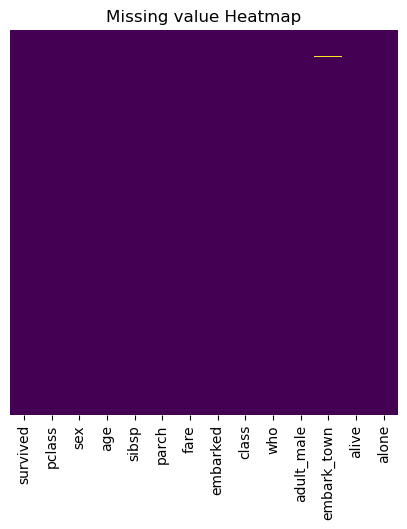

In [24]:
#check missing values
print("Missing values per column:\n",df.isnull().sum())
print("\n percentage missing :\n",(df.isnull().sum()/len(df)*100))
#visualize missing values
plt.figure(figsize=(5,5))
sns.heatmap(df.isnull(),cbar=False,cmap="viridis",yticklabels=False)
plt.title("Missing value Heatmap")
plt.show()

3. Handle Missing Values

In [11]:
# method 1 : Drop rows any missing values
df_drop_any=df.dropna()
print("After droping any NA:\n",df_drop_any)
print("shape:",df_drop_any.shape)
#method2: Drop rows where ALL values are missing (none here)
df_drop_all=df.dropna(how="all")
print("\n After droping all NA:\n",df_drop_any)
# Method 3: Drop columns with missing values
df_drop_cols = df.dropna(axis=1)
print("\nAfter dropping columns with NA:\n", df_drop_cols)
print("Shape:", df_drop_cols.shape)

After droping any NA:
     Name    Age   Salary  Experience Department
0  Alice   20.0  50000.0         2.0         IT
1    Bob   22.0  60000.0         3.0         HR
8    Ivy   24.0  65000.0         5.0         IT
9   Jack  100.0  52000.0         2.0         IT
shape: (4, 5)

 After droping all NA:
     Name    Age   Salary  Experience Department
0  Alice   20.0  50000.0         2.0         IT
1    Bob   22.0  60000.0         3.0         HR
8    Ivy   24.0  65000.0         5.0         IT
9   Jack  100.0  52000.0         2.0         IT

After dropping columns with NA:
       Name
0    Alice
1      Bob
2  Charlie
3    David
4      Eve
5    Frank
6    Grace
7    Henry
8      Ivy
9     Jack
Shape: (10, 1)


In [13]:
# Method 4: Fill missing values (Imputation)
df_filled = df.copy()
# Fill Age with mean
age_mean = df_filled["Age"].mean()
df_filled["Age"] = df_filled["Age"].fillna(age_mean)
print("Age filled with mean:", age_mean)
# Fill Salary with median
salary_median = df_filled["Salary"].median()
df_filled["Salary"] = df_filled["Salary"].fillna(salary_median)
print("Salary filled with median:", salary_median)
# Fill Experience with mode (most frequent)
exp_mode = df_filled["Experience"].mode()[0]
df_filled["Experience"] = df_filled["Experience"].fillna(exp_mode)
print("Experience filled with mode:", exp_mode)
# Fill Department with "Unknown"
df_filled["Department"] = df_filled["Department"].fillna("Unknown")
print("\nAfter filling:\n", df_filled)
print("\nMissing values after filling:\n", df_filled.isnull().sum())

Age filled with mean: 32.125
Salary filled with median: 56500.0
Experience filled with mode: 2.0

After filling:
       Name      Age   Salary  Experience Department
0    Alice   20.000  50000.0         2.0         IT
1      Bob   22.000  60000.0         3.0         HR
2  Charlie   32.125  55000.0         2.0         IT
3    David   21.000  56500.0         1.0         IT
4      Eve   23.000  70000.0         4.0    Unknown
5    Frank   25.000  45000.0         2.0         HR
6    Grace   32.125  58000.0         3.0         IT
7    Henry   22.000  56500.0         2.0         HR
8      Ivy   24.000  65000.0         5.0         IT
9     Jack  100.000  52000.0         2.0         IT

Missing values after filling:
 Name          0
Age           0
Salary        0
Experience    0
Department    0
dtype: int64


4. Detect & Handle Outliers


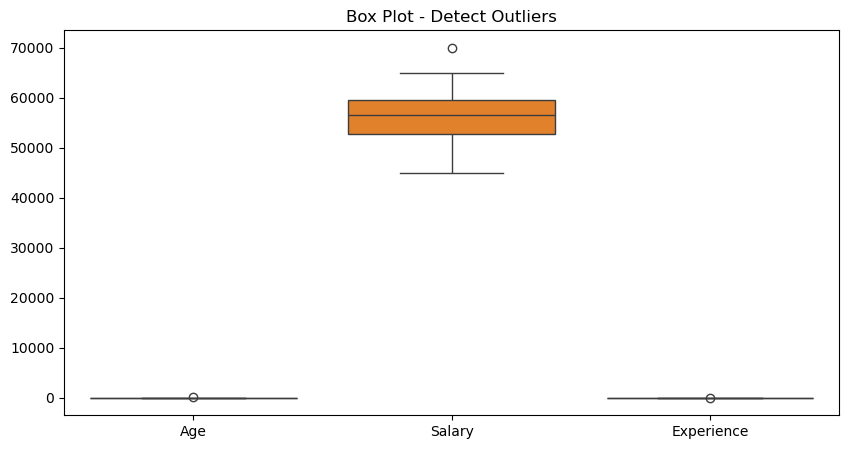

Age outliers (below 9.484375 or above 42.859375):
    Name    Age   Salary  Experience Department
9  Jack  100.0  52000.0         2.0         IT


In [14]:
# Box plot to detect outliers
plt.figure(figsize=(10, 5))
sns.boxplot(data=df_filled[["Age", "Salary", "Experience"]])
plt.title("Box Plot - Detect Outliers")
plt.show()

# Statistical method: IQR (Interquartile Range)
def detect_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = data[(data[column] < lower) | (data[column] > upper)]
    return outliers, lower, upper

outliers_age, lower_age, upper_age = detect_outliers_iqr(df_filled, "Age")
print(f"Age outliers (below {lower_age} or above {upper_age}):\n", outliers_age)

After capping Age:
       Name        Age   Salary  Experience Department
0    Alice  20.000000  50000.0         2.0         IT
1      Bob  22.000000  60000.0         3.0         HR
2  Charlie  32.125000  55000.0         2.0         IT
3    David  21.000000  56500.0         1.0         IT
4      Eve  23.000000  70000.0         4.0    Unknown
5    Frank  25.000000  45000.0         2.0         HR
6    Grace  32.125000  58000.0         3.0         IT
7    Henry  22.000000  56500.0         2.0         HR
8      Ivy  24.000000  65000.0         5.0         IT
9     Jack  42.859375  52000.0         2.0         IT


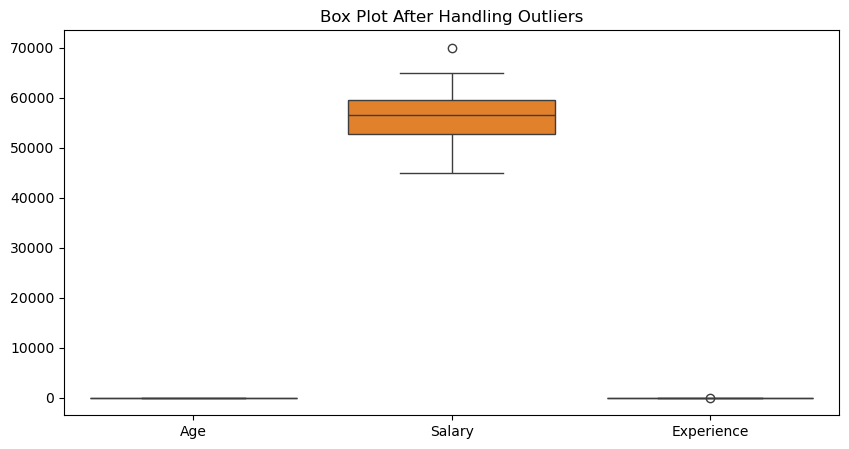

In [20]:
# Handle outliers: Cap them (Winsorization)
df_clean = df_filled.copy()

# Cap Age at upper bound
df_clean.loc[df_clean["Age"] > upper_age, "Age"] = upper_age
print("After capping Age:\n", df_clean)

# Verify with box plot
plt.figure(figsize=(10, 5))
sns.boxplot(data=df_clean[["Age", "Salary", "Experience"]])
plt.title("Box Plot After Handling Outliers")
plt.show()

## 5. Challenge: Clean a Real Dataset

In [19]:
import pandas as pd
import seaborn as sns
# Load Titanic Dataset
titanic = sns.load_dataset("titanic")
print("Original Shape:", titanic.shape)
print("\nFirst 5 Rows:")
print(titanic.head())
print("\nMissing Values:")
print(titanic.isnull().sum())
# 1. Drop columns with more than 50% missing values
threshold = len(titanic) * 0.5
# Create a copy to avoid SettingWithCopyWarning
df = titanic.dropna(axis=1, thresh=threshold).copy()
print("\nColumns after dropping >50% missing values:")
print(df.columns)
# 2. Fill 'age' with median
df["age"] = df["age"].fillna(df["age"].median())
# 3. Fill 'embarked' with mode
df["embarked"] = df["embarked"].fillna(df["embarked"].mode()[0])
# Check missing values after filling
print("\nMissing Values After Filling:")
print(df.isnull().sum())
# 4. Detect outliers in 'fare' using IQR
Q1 = df["fare"].quantile(0.25)
Q3 = df["fare"].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers = df[(df["fare"] < lower_bound) | (df["fare"] > upper_bound)]
print("\nNumber of Fare Outliers:", len(outliers))
print("\nSample Fare Outliers:")
print(outliers[["fare"]].head())
# 5. Create a clean dataset ready for ML
# Drop any remaining missing values
df_clean = df.dropna().copy()
print("\nClean Dataset Shape:", df_clean.shape)
print("\nRemaining Missing Values:")
print(df_clean.isnull().sum())
print("\nFirst 5 Rows of Clean Dataset:")
print(df_clean.head())
# Save cleaned dataset (Optional)
df_clean.to_csv("titanic_clean.csv", index=False)
print("\nClean dataset saved as 'titanic_clean.csv'")

Original Shape: (891, 15)

First 5 Rows:
   survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   
4         0       3    male  35.0      0      0   8.0500        S  Third   

     who  adult_male deck  embark_town alive  alone  
0    man        True  NaN  Southampton    no  False  
1  woman       False    C    Cherbourg   yes  False  
2  woman       False  NaN  Southampton   yes   True  
3  woman       False    C  Southampton   yes  False  
4    man        True  NaN  Southampton    no   True  

Missing Values:
survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class    